## Практическая работа

## Цели практической работы

*  решить реальную задачу;
*  потренироваться в обработке данных;
*  обучить различные модели классификации, подобрать гиперпараметры и выбрать лучшую модель;
*  добиться наилучшего качества в задаче.

## Что входит в практическую работу

*  исследование датасета и обработка данных (работа с пропущенными и ошибочными значениями);
*  обучение различных моделей классификации с параметрами по умолчанию;
*  подбор гиперпараметров моделей;
*  смешивание моделей;
*  оценка качества моделей.

## Что оценивается

*  Выполнены все этапы задания: код запускается, отрабатывает без ошибок; подробно и обоснованно написаны текстовые выводы, где это требуется.

## Формат сдачи
Выполните предложенные задания: впишите свой код (или, если требуется, текст) в ячейки после комментариев. 

*Комментарии — это текст, который начинается с символа #. Например: # ваш код здесь.*

Сохраните изменения, используя опцию Save and Checkpoint из вкладки меню File или кнопку Save and Checkpoint на панели инструментов. Итоговый файл в формате .ipynb (файл Jupyter Notebook) загрузите в личный кабинет и отправьте на проверку.

### 1. Загрузите тренировочные и тестовые датасеты

In [1]:
import pandas as pd
#!pip install category_encoders
import numpy as np
from category_encoders import TargetEncoder
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.impute import SimpleImputer

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt   # для работы с графиками

import warnings
warnings.filterwarnings("ignore")

Xtrain = pd.read_csv("TrainData.csv")
Xtest = pd.read_csv("TestData.csv")

### 2. Изучите тренировочные и тестовые данные на наличие:
- пропусков,
- ошибочных значений.

Обработайте пропуски и ошибочные значения способом, выбранным по своему усмотрению.

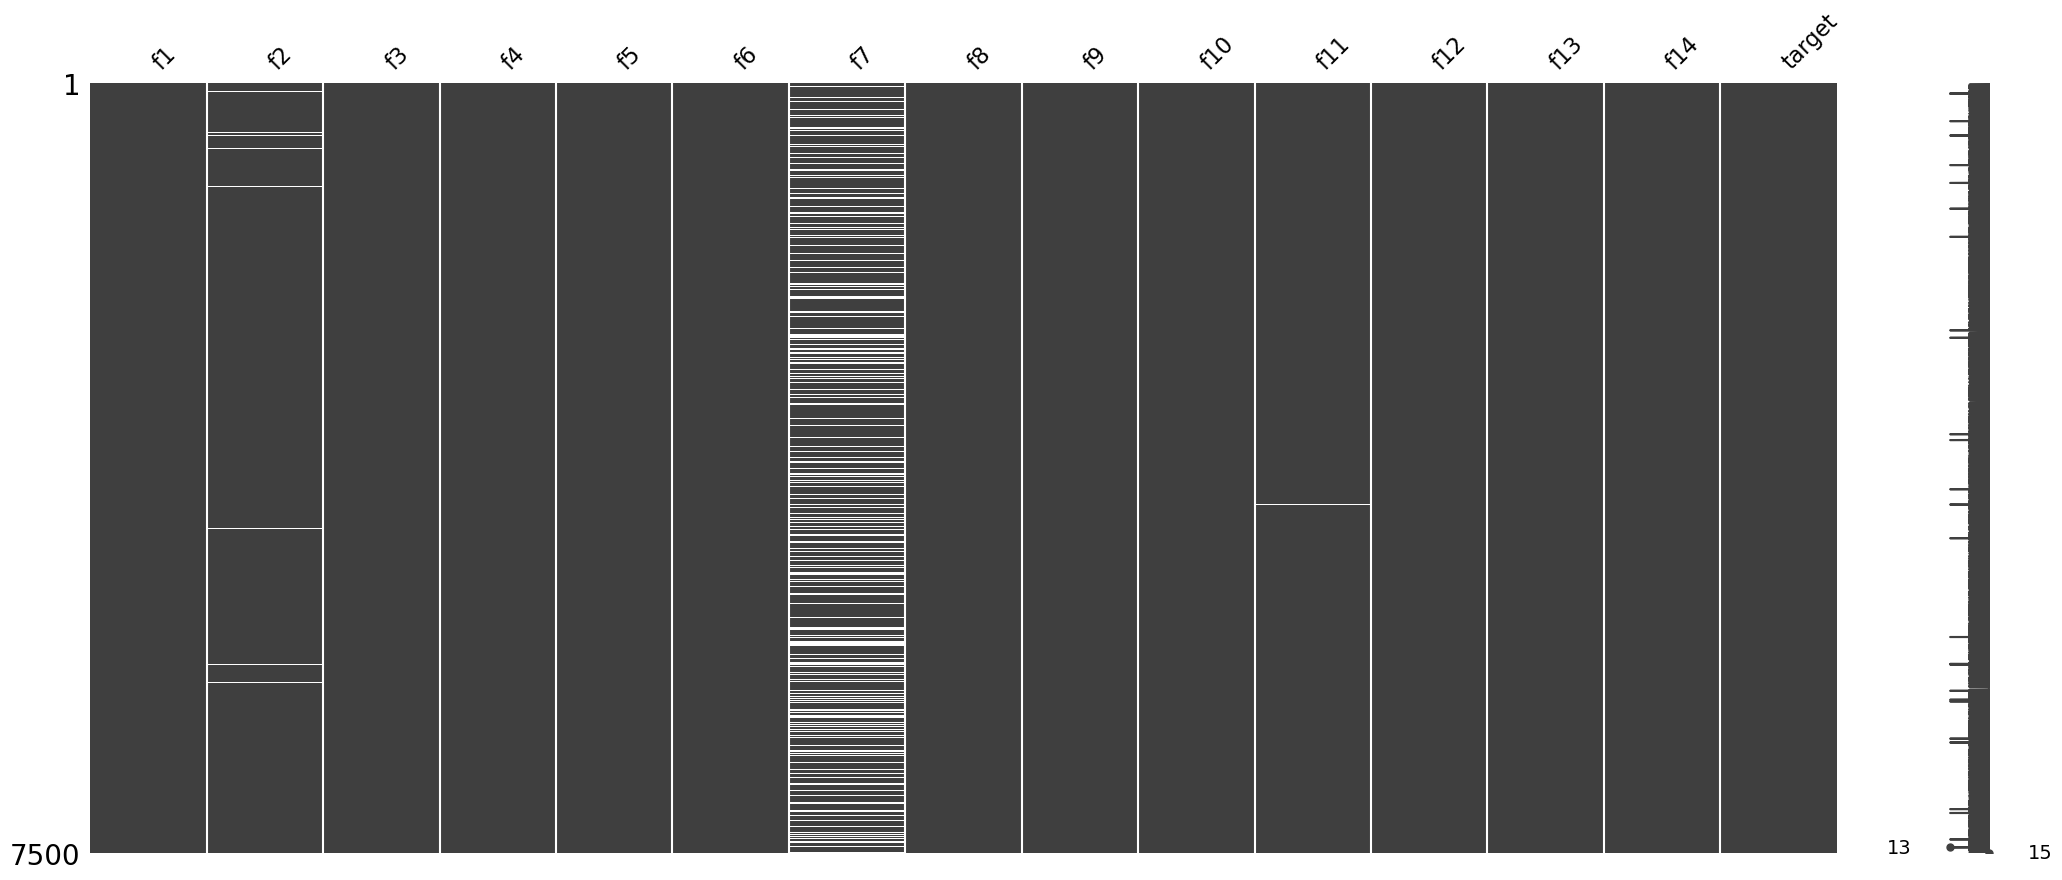

In [2]:
# Ваш код здесь
msno.matrix(Xtrain); #Матрица пропущенных значений

In [3]:
Xtrain

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,target
0,50,218.593930,273536,0.104575,4,0.445026,0.274531,0.444334,5.970149,0.300298,0.0,0,49,0.100000,0
1,32,276.771005,173314,0.224684,11,0.445026,0.439103,0.444334,5.970149,0.300298,0.0,0,60,0.244418,0
2,38,218.593930,28887,0.032491,7,0.445026,0.274531,0.444334,25.606721,0.300298,0.0,0,50,0.244418,0
3,19,218.593930,427862,0.179322,10,0.049127,0.044987,0.009499,25.606721,0.300298,0.0,0,35,0.244418,0
4,44,218.593930,109339,0.032491,7,0.098837,0.115721,0.066581,5.970149,0.113590,0.0,0,46,0.185185,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,48,218.593930,329778,0.171817,9,0.066372,NaN,0.066581,25.606721,0.113590,0.0,0,40,0.244418,0
7496,25,218.593930,104439,0.179322,10,0.049127,0.131370,0.103024,25.606721,0.113590,0.0,0,50,0.244418,0
7497,50,218.593930,162632,0.171817,9,0.445026,0.482222,0.444334,25.606721,0.300298,0.0,0,45,0.244418,0
7498,51,276.771005,174824,0.171817,9,0.049127,0.093897,0.103024,25.606721,0.300298,8614.0,0,40,0.244418,1


In [4]:
Xtrain.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,target
count,7500.000000,7425.000000,7.500000e+03,7500.000000,7500.000000,7500.000000,5625.000000,7500.000000,7500.000000,7500.000000,7490.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,38.579600,238.905308,1.903850e+05,0.238933,10.083200,0.238934,0.240556,0.238933,23.893333,0.238933,1068.693992,88.974933,40.670800,0.238955,0.238933
std,13.647719,76.198282,1.058674e+05,0.151738,2.546071,0.190283,0.147371,0.193365,4.451530,0.087708,7430.344770,404.517032,12.330051,0.041685,0.426460
min,17.000000,64.259070,1.930200e+04,0.000029,1.000000,0.049127,0.000000,0.009499,5.970149,0.113590,0.000000,0.000000,1.000000,0.000080,0.000000
25%,28.000000,218.593930,1.180190e+05,0.171817,9.000000,0.049127,0.115721,0.066581,25.606721,0.113590,0.000000,0.000000,40.000000,0.244418,0.000000
50%,37.000000,218.593930,1.795685e+05,0.179322,10.000000,0.098837,0.241573,0.103024,25.606721,0.300298,0.000000,0.000000,40.000000,0.244418,0.000000
75%,47.000000,218.593930,2.394418e+05,0.239316,12.000000,0.445026,0.439103,0.444334,25.606721,0.300298,0.000000,0.000000,45.000000,0.244418,0.000000
max,90.000000,575.396825,1.226583e+06,0.729323,16.000000,0.445026,0.482222,0.484375,25.606721,0.300298,99999.000000,4356.000000,99.000000,0.466666,1.000000


In [5]:
Xtest.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,target
count,2500.000000,2.500000e+03,2500.000000,2.500000e+03,2500.000000,2.500000e+03,2.500000e+03,2.500000e+03,2.500000e+03,2.500000e+03,2500.000000,2500.00000,2500.000000,2.500000e+03,2500.000000
mean,38.069200,2.389333e+02,191561.425200,2.389333e-01,10.056800,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,1022.667200,83.76080,40.108800,2.389333e-01,0.234800
std,13.442168,5.912898e-12,107542.508483,1.424146e-14,2.554875,1.424146e-14,1.424146e-14,1.424146e-14,9.594246e-14,1.424146e-14,6786.871929,387.72358,12.109914,1.424146e-14,0.423959
min,17.000000,2.389333e+02,19302.000000,2.389333e-01,1.000000,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,0.000000,0.00000,3.000000,2.389333e-01,0.000000
25%,27.000000,2.389333e+02,119098.750000,2.389333e-01,9.000000,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,0.000000,0.00000,38.750000,2.389333e-01,0.000000
50%,37.000000,2.389333e+02,177510.500000,2.389333e-01,10.000000,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,0.000000,0.00000,40.000000,2.389333e-01,0.000000
75%,47.000000,2.389333e+02,238851.250000,2.389333e-01,12.000000,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,0.000000,0.00000,45.000000,2.389333e-01,0.000000
max,90.000000,2.389333e+02,910398.000000,2.389333e-01,16.000000,2.389333e-01,2.389333e-01,2.389333e-01,2.389333e+01,2.389333e-01,99999.000000,2559.00000,99.000000,2.389333e-01,1.000000


In [6]:
print(Xtrain.dtypes)

f1          int64
f2        float64
f3          int64
f4        float64
f5          int64
f6        float64
f7        float64
f8        float64
f9        float64
f10       float64
f11       float64
f12         int64
f13         int64
f14       float64
target      int64
dtype: object


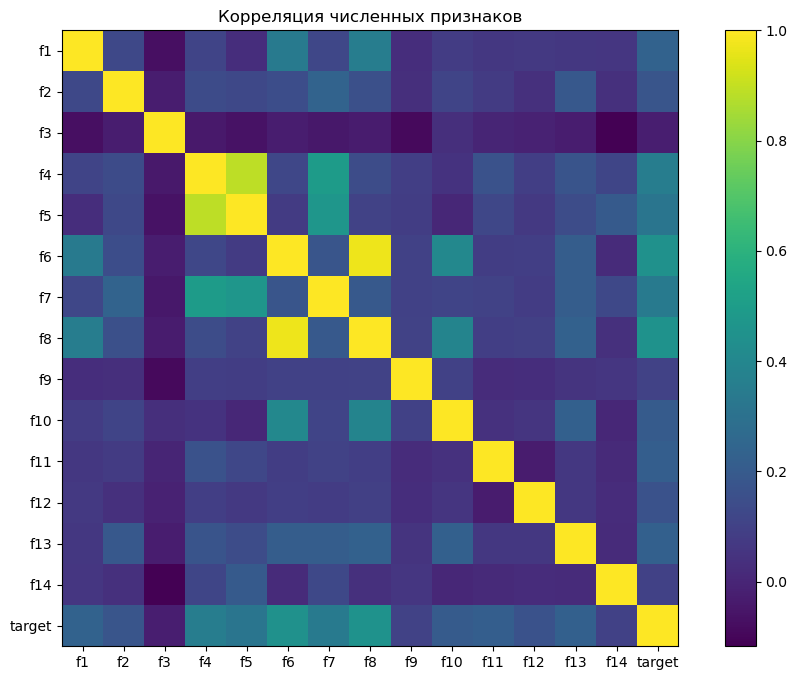

In [7]:
plt.figure(figsize=(12, 8))

columns = Xtrain.corr().columns.tolist()
plt.imshow(Xtrain.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

In [8]:
imputerFunc = SimpleImputer(missing_values = np.nan, strategy ='median') 
imputerFunc = imputerFunc.fit(Xtrain) 
Xtrain = pd.DataFrame(imputerFunc.transform(Xtrain), columns=Xtrain.columns) 
Xtrain.drop_duplicates()
Xtrain

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,target
0,50.0,218.593930,273536.0,0.104575,4.0,0.445026,0.274531,0.444334,5.970149,0.300298,0.0,0.0,49.0,0.100000,0.0
1,32.0,276.771005,173314.0,0.224684,11.0,0.445026,0.439103,0.444334,5.970149,0.300298,0.0,0.0,60.0,0.244418,0.0
2,38.0,218.593930,28887.0,0.032491,7.0,0.445026,0.274531,0.444334,25.606721,0.300298,0.0,0.0,50.0,0.244418,0.0
3,19.0,218.593930,427862.0,0.179322,10.0,0.049127,0.044987,0.009499,25.606721,0.300298,0.0,0.0,35.0,0.244418,0.0
4,44.0,218.593930,109339.0,0.032491,7.0,0.098837,0.115721,0.066581,5.970149,0.113590,0.0,0.0,46.0,0.185185,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,48.0,218.593930,329778.0,0.171817,9.0,0.066372,0.241573,0.066581,25.606721,0.113590,0.0,0.0,40.0,0.244418,0.0
7496,25.0,218.593930,104439.0,0.179322,10.0,0.049127,0.131370,0.103024,25.606721,0.113590,0.0,0.0,50.0,0.244418,0.0
7497,50.0,218.593930,162632.0,0.171817,9.0,0.445026,0.482222,0.444334,25.606721,0.300298,0.0,0.0,45.0,0.244418,0.0
7498,51.0,276.771005,174824.0,0.171817,9.0,0.049127,0.093897,0.103024,25.606721,0.300298,8614.0,0.0,40.0,0.244418,1.0


In [9]:
ytrain = Xtrain['target']
Xtrain = Xtrain.drop(['target'], axis=1)


In [10]:
Xtrain = Xtrain.drop(['f6'], axis=1)

### 3. Оцените баланс классов в задаче
- Затем попытайтесь устно ответить на вопрос, можно ли использовать accuracy как метрику качества в задаче? 

<Axes: >

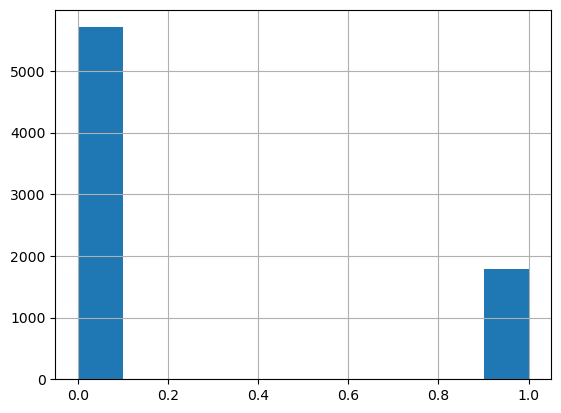

In [11]:
# Ваш код здесь
ytrain.hist()

### 3. Постройте baseline-модель:
- разбейте TrainData на тренировочные (Train) и тестовые данные (Test); 
- обучите KNN, LogisticRegression и SVC с параметрами по умолчанию на тренировочных данных (Train);
- примените модели на тестовых данных (Test) и вычислите значение метрики f1.

In [12]:
from sklearn.metrics import f1_score

# Ваш код здесь

In [13]:
model_logreg = LogisticRegression()
model_SVC = SVC()
model_knn = KNeighborsClassifier()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xtrain, ytrain, train_size=0.7, random_state=123)

In [14]:
model_logreg.fit(X_train, y_train)
model_SVC.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [15]:
y_pred_lr = model_logreg.predict(X_test)
y_pred_svc = model_SVC.predict(X_test)
y_pred_knn = model_knn.predict(X_test)


In [16]:
f1_model_logreg = f1_score(y_test, y_pred_lr)
print(f' f1 для LogisticRegression = {f1_model_logreg}')
f1_model_svc = f1_score(y_test, y_pred_svc)
print(f' f1 для SVC = {f1_model_svc}')
f1_model_knn = f1_score(y_test, y_pred_knn)
print(f' f1 для KNeighborsClassifier = {f1_model_knn}')

 f1 для LogisticRegression = 0.36556291390728474
 f1 для SVC = 0.0983050847457627
 f1 для KNeighborsClassifier = 0.3059125964010283


### 4. Улучшите модели
Попробуйте улучшить качество обученных моделей:
- можете подбирать гиперпараметры моделей (лучше это делать по кросс-валидации на Train, то есть с помощью использования GridSearchCV на Train);
- можете задавать class_weights;
- можете вручную или при помощи методов Python генерировать новые признаки и/или удалять существующие.

Это самая важная и творческая часть задания. Проводите как можно больше экспериментов!

Проведите минимиум три эксперимента: для каждого типа модели минимум один эксперимент.

In [17]:
# Ваш код здесь

In [18]:
from sklearn.model_selection import GridSearchCV

# Задаем значения параметров, которые хотим перебрать
param_grid_logreg = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'class_weight':['balanced', None]}
param_grid_knn = {'n_neighbors': np.arange(11, 41, 2), 'weights': ['uniform', 'distance']}
param_grid_SVC = {'C': [1, 10], 'class_weight':['balanced', None]}


# Создаем объекты GridSearchCV для каждой модели
grid_logreg = GridSearchCV(model_logreg, param_grid_logreg, cv=5, scoring='f1', verbose=0)
grid_SVC = GridSearchCV(model_SVC, param_grid_SVC, cv=5, scoring='f1', verbose=0)
grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, scoring='f1', verbose=0)


In [19]:
# Запускаем поиск по сетке на каждой модели
grid_logreg.fit(X_train, y_train)
print("Лучшие параметры для Logistic Regression:", grid_logreg.best_params_)
print("Лучший результат для Logistic Regression:", grid_logreg.best_score_)

Лучшие параметры для Logistic Regression: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}
Лучший результат для Logistic Regression: 0.45251590633930966


In [20]:
grid_knn.fit(X_train, y_train)
print("Лучшие параметры для KNN:", grid_knn.best_params_)
print("Лучший результат для KNN:", grid_knn.best_score_)


Лучшие параметры для KNN: {'n_neighbors': 11, 'weights': 'distance'}
Лучший результат для KNN: 0.3296695391274365


In [21]:
grid_SVC.fit(X_train, y_train)
print("Лучшие параметры для SVC:", grid_SVC.best_params_)
print("Лучший результат для SVC:", grid_SVC.best_score_)

Лучшие параметры для SVC: {'C': 10, 'class_weight': 'balanced'}
Лучший результат для SVC: 0.3225080612926526


### 5. Оцените на отложенной выборке качество наилучшей модели
В пунктах 3 и 4 вы построили много разных моделей.

Возьмите ту, которая дала наилучшее качество на тестовых данных (Test). Примените её на отложенной выборке (TestData) и выведите на экран значение метрики f1.

In [22]:
# Ваш код здесь
ytest = Xtest['target']
Xtest = Xtest.drop(['target', 'f6'], axis=1)
model_logreg = LogisticRegression(C=1, class_weight='balanced', penalty='l2')
model_logreg.fit(X_train, y_train)


LogisticRegression(C=1, class_weight='balanced')

In [23]:
y_pred_test = model_logreg.predict(Xtest)
f1_model_logreg_test = f1_score(ytest, y_pred_test)
print(f' f1 для TestData = {f1_model_logreg_test}')

 f1 для TestData = 0.48553281580804525


### 6. Выполните хитрый трюк
Часто смешивание различных моделей даёт улучшение итогового предсказания. Попробуйте смешать две лучшие модели по формуле:
$$pred_{final} = \alpha\cdot pred_1 + (1-\alpha)\cdot pred_2$$.

Значение $\alpha$ подберите в цикле по Test-выборке. Оцените качество на отложенной выборке.

Удалось ли добиться улучшения качества?

In [24]:
# Ваш код здесь
model_knn = KNeighborsClassifier(n_neighbors=11, weights='distance')
model_knn.fit(X_train, y_train)

y_pred_lr = model_logreg.predict(X_test)
y_pred_knn = model_knn.predict(X_test)
f1_preds_fin = []
alphas = []
for alpha in np.arange(0.1, 1, 0.1):
    pred_fin = alpha * y_pred_lr + (1 - alpha) * y_pred_knn
    pred_fin = pred_fin.round().astype(int)
    f1_pred_fin = f1_score(y_test, pred_fin)
    f1_preds_fin.append(f1_pred_fin)
    alphas.append(alpha)
print(f'best pred_final = {max(f1_preds_fin)}')
print(f'alpha = {alphas[(f1_preds_fin.index(max(f1_preds_fin)))]}')

best pred_final = 0.4489795918367347
alpha = 0.6


In [45]:
y_pred_lr_test = model_logreg.predict(Xtest)
y_pred_knn_test = model_knn.predict(Xtest)
pred_fin_test = 0.6 * y_pred_lr_test + (1 - 0.6) * y_pred_knn_test
pred_fin_test = pred_fin_test.round().astype(int)
print(f'f1 на отложенной выборке(TestData) при alpha=0.6 после смешивания моделей '
      f'логистической регрессии и ближайших соседей \n{f1_score(ytest, pred_fin_test)}')

f1 на отложенной выборке(TestData) при alpha=0.6 после смешивания моделей логистической регрессии и ближайших соседей 
0.48553281580804525


In [46]:
print(classification_report(ytest, pred_fin_test))

              precision    recall  f1-score   support

           0       0.85      0.75      0.80      1913
           1       0.41      0.59      0.49       587

    accuracy                           0.71      2500
   macro avg       0.63      0.67      0.64      2500
weighted avg       0.75      0.71      0.72      2500



In [50]:
import itertools
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
 
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
 
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
 
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

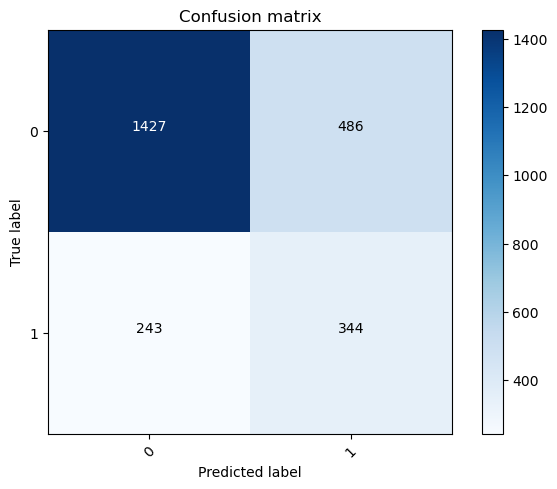

In [52]:
plot_confusion_matrix(confusion_matrix(ytest, pred_fin_test), classes=['0','1'],
                          title='Confusion matrix')

### 7. Сделайте выводы

Запишите в отдельной ячейке текстом выводы о проделанной работе. Для этого ответьте на вопросы:
- Какие подходы вы использовали для улучшения работы baseline-моделей?
- Какого максимального качества удалось добиться на Test-данных?
- Какое при этом получилось качество на отложенной выборке? 
- Ваша модель переобучилась, недообучилась или обучилась как надо?

In [ ]:
# Ваш текст здесь

In [54]:
#Для улучшения работы baseline-моделей использовались кросс-валидации на Train с перебором параметров:
#    - для модели логистической регрессии "C"(0.1, 1, 10), регуляризация ('l1', 'l2'), веса классов для несбалансированых классов и без;
#    - для модели ближайших соседей изменялось количество соседей, и параметры весов;
#    - для модели опорных векторов менялся параметр"C"(0.1, 1, 10), а также параметр  class_weight='balanced' и class_weight=None
#    - был удален признак "f6" из датасета
#На Test-данных максимально удалось добиться  качества f1=0.45251590633930966
#При этом на отложенной выборке качество составило 0.48553281580804525
#Следовательно модель обучилась как надо

Важный комментарий! В реальных задачах не следует ожидать, что машинным обучением всегда удастся решить задачу с хорошим качеством. Но использовать все имеющиеся у вас в арсенале методы для достижения наилучшего результата нужно.